In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt
import random
import pickle
import torch.nn.functional as F
import warnings
warnings.filterwarnings("ignore")


hyp = dict(
    seed          = 42,
    epochs        = 40,     
    lr            = 1e-4,  
    batch_size    = 32,
    shared_dim    = 64,
    num_heads     = 4,
    dropout       = 0.2,     
    weight_decay  = 1e-2,   
    label_smooth  = 0.05,    
    mixup_alpha   = 0.1,     
    modal_drop_p  = 0.05,   
    patience      = 8,      
    warmup_epochs = 3,      
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(hyp["seed"])

Device: cuda


# 함수 정의

In [ ]:
class FeatureDataset(Dataset):
    def __init__(self, vid, aud, txt, y):
        self.vid       = torch.tensor(vid, dtype=torch.float32)
        self.aud       = torch.tensor(aud, dtype=torch.float32)
        self.txt       = torch.tensor(txt, dtype=torch.float32)
        self.y         = torch.tensor(np.array(y), dtype=torch.long)

    def __len__(self): return len(self.y)

    def __getitem__(self, i):
        v, a, t = self.vid[i], self.aud[i], self.txt[i]
        return v, a, t, self.y[i]
    
class ModalEncoder(nn.Module):
    def __init__(self, in_dim, shared_dim=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(in_dim), #평균0, 분산1로 맞춰 스케일링
            nn.Linear(in_dim, shared_dim), #차원 축소
            nn.GELU(), #활성화 함수
            nn.Dropout(dropout), #과적함 방지
            nn.Linear(shared_dim, shared_dim), #차원 유지하며 학습
            nn.GELU(), # 활성화 함수
        )
    def forward(self, x): 
        return self.net(x)

    
class SelfAttentionFusionModel(nn.Module):
    def __init__(self, in_dim, shared_dim=128, num_heads=4, num_classes=2,
                 dropout=0.3, modal_drop_p=0.10):
        super().__init__()
        self.video_enc    = ModalEncoder(in_dim, shared_dim, dropout)
        self.audio_enc    = ModalEncoder(in_dim, shared_dim, dropout)
        self.text_enc     = ModalEncoder(in_dim, shared_dim, dropout) # 모두 64차원으로 통일
        self.modal_embed  = nn.Parameter(torch.randn(1, 3, shared_dim)) # 임베딩
        self.modal_drop_p = modal_drop_p #드롭아웃 확률 ->모달리티 간 의존성 방지 ex)비디오 없이 학습

        self.self_attn = nn.MultiheadAttention(shared_dim, num_heads, dropout=0.1, batch_first=True)
        self.norm1     = nn.LayerNorm(shared_dim)
        self.ffn       = nn.Sequential(
            nn.Linear(shared_dim, shared_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(shared_dim * 4, shared_dim),
        )
        self.norm2 = nn.LayerNorm(shared_dim)

        self.classifier = nn.Sequential(
        nn.Linear(shared_dim * 3, 64),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(64, num_classes),
        )

    def forward(self, video, audio, text):
        v = self.video_enc(video)
        a = self.audio_enc(audio)
        t = self.text_enc(text)

        #과적합 방지 코드
        if self.training and self.modal_drop_p > 0: # 학습중이고 드롭 아웃이 0보다 크면
            keep = torch.rand(3, device=v.device) >= self.modal_drop_p # 각 모달리티 유지 여부 결정 ex:[True, False, True]
            if not keep.any():#[False, False, False] 모달 세 개 다 꺼졌으면
                keep[torch.randint(3, (1,)).item()] = True # 무작위로 하나 골라 true로 켜줌 -> 최소한 하나는 살아있도록 보장

            #나온 마스크(0,1)을 각각 모달에 곱함
            v = v * keep[0].float()
            a = a * keep[1].float()
            t = t * keep[2].float()

        H = torch.stack([v, a, t], dim=1) + self.modal_embed # 각모달 합치고 포지셔널 임베딩 더해줌
        attn_out, _ = self.self_attn(H, H, H, need_weights=False)
        H = self.norm1(H + attn_out)
        H = self.norm2(H + self.ffn(H))
        return self.classifier(H.reshape(H.size(0), -1)) # [0번 감정 확률, 1번 감정 확률]

# 학습률 스케줄러 (초반 워밍업 + 이후 코사인 감쇠) -> 안정적 학습과 빠른 수렴
def get_warmup_cosine_scheduler(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs: # 예열 단계
            return (epoch + 1) / warmup_epochs          # 선형 증가
        progress = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1) #현재 진행률 계산(0~1)
        return 0.5 * (1.0 + np.cos(np.pi * progress))  # cosine 감소
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

#과적합 방지 -> 데이터 증강, 각 모달끼리 섞어서 훈련
def mixup_batch(v, a, t, y, alpha):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0 # 데이터 섞을 때 섞는 정도 결정하는 람다값, alpha가 클수록 더 섞임
    idx = torch.randperm(v.size(0), device=v.device) # 배치 내에서 무작위로 인덱스 섞음 -> 각 샘플이 다른 샘플과 섞이도록
    return (
        lam * v + (1 - lam) * v[idx],#비디오끼리
        lam * a + (1 - lam) * a[idx],#오디오끼리
        lam * t + (1 - lam) * t[idx],#텍스트끼리
        y, y[idx], lam
    )

def mixup_loss(criterion, out, y_a, y_b, lam):
    return lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b) # 섞인 라벨에 맞춰 손실 계산


def evaluate(model, loader, criterion):
    with torch.no_grad(): # 기울기 계산 안함
        model.eval()
        total_loss = correct = total = 0
        all_preds, all_targets = [], [] # f1score 계산
        for v, a, t, yb in loader:
            v, a, t, yb = v.to(device), a.to(device), t.to(device), yb.to(device)
            out   = model(v, a, t) # 모델 예측
            loss  = criterion(out, yb) # 손실 계산
            preds = out.argmax(1)   #가장 높은 확률의 클래스 선택
            total_loss += loss.item() * yb.size(0) # 배치 손실에 배치 크기 곱해서 누적
            correct    += (preds == yb).sum().item() # 맞춘 개수 누적
            total      += yb.size(0) # 총 샘플 수 누적
            all_preds.extend(preds.cpu().tolist()) # 예측값 리스트에 추가
            all_targets.extend(yb.cpu().tolist()) # 실제값 리스트에 추가
        return {
            "loss": total_loss / total,
            "acc":  correct / total * 100,
            "f1":   f1_score(all_targets, all_preds, average="macro") * 100,
        }

def train_fusion(model, train_loader, val_loader, test_loader, hyp):
    criterion = nn.CrossEntropyLoss(label_smoothing=hyp["label_smooth"])
    optimizer = optim.AdamW(
        model.parameters(), lr=hyp["lr"], weight_decay=hyp["weight_decay"]
    )
    scheduler = get_warmup_cosine_scheduler(
        optimizer, hyp["warmup_epochs"], hyp["epochs"]
    )

    # ★ val_smooth 완전히 제거하고 핵심 지표 9개만 딱 남겼습니다.
    history = {k: [] for k in [
        "train_loss", "val_loss",  "test_loss",
        "train_acc",  "val_acc",   "test_acc",
        "train_f1",   "val_f1",    "test_f1"
    ]}

    best_val_acc = 0.0   # 조기 종료 기준용
    best_state   = None
    no_imp       = 0

    for epoch in range(hyp["epochs"]):
        # ── Train ────────────────────────────────────────────
        model.train()
        total_loss = correct = total = 0
        all_preds, all_targets = [], []

        for v, a, t, yb in train_loader:
            v, a, t, yb = v.to(device), a.to(device), t.to(device), yb.to(device)
            v_m, a_m, t_m, ya, yb_mix, lam = mixup_batch(v, a, t, yb, hyp["mixup_alpha"])
            out  = model(v_m, a_m, t_m)
            loss = mixup_loss(criterion, out, ya, yb_mix, lam) #섞인 비율만큼 오차 계산

            optimizer.zero_grad() # 그래디언트 초기화
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0) # 그래디언트 클리핑(기울기 폭발 방지)
            optimizer.step()

            preds = out.argmax(1)
            total_loss += loss.item() * yb.size(0)

            lam_tensor = torch.tensor(lam, device=device) # 람다값 텐서로 변환
            target_pseudo = torch.where(lam_tensor > 0.5, ya, yb_mix) # 람다가 0.5보다 크면 ya, 아니면 yb_mix 선택

            correct += (
                lam * (preds == ya).float() + (1 - lam) * (preds == yb_mix).float()
            ).sum().item()
            total += yb.size(0)

            all_preds.extend(preds.cpu().tolist())
            all_targets.extend(target_pseudo.cpu().tolist())

        scheduler.step()
        current_lr = optimizer.param_groups[0]["lr"]
        
        # Train 지표 계산
        train_f1 = f1_score(all_targets, all_preds, average="macro") * 100
        train_res = {"loss": total_loss / total, "acc": correct / total * 100, "f1": train_f1}
        
        # Val, Test 지표 계산
        val_res   = evaluate(model, val_loader,  criterion)
        test_res  = evaluate(model, test_loader, criterion)

        # 히스토리 기록 
        for key, val in [
            ("train_loss", train_res["loss"]), ("train_acc", train_res["acc"]), ("train_f1", train_res["f1"]),
            ("val_loss",   val_res["loss"]),   ("val_acc",   val_res["acc"]),   ("val_f1",   val_res["f1"]),
            ("test_loss",  test_res["loss"]),  ("test_acc",  test_res["acc"]),  ("test_f1",  test_res["f1"]),
        ]:
            history[key].append(val)

        # ── Early Stopping ──────
        if val_res["f1"] > best_val_acc:
            best_val_acc = val_res["f1"]
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_imp       = 0
            flag = " ✓" # 갱신되었을 때 체크 표시
        else:
            no_imp += 1
            flag = ""

        # 깔끔해진 출력문
        print(
            f"Ep {epoch+1:3d} "
            f"Loss {train_res['loss']:.3f}/{val_res['loss']:.3f}/{test_res['loss']:.3f} | "
            f"Acc {train_res['acc']:.1f}/{val_res['acc']:.1f}/{test_res['acc']:.1f}% | "
            f"F1 {train_res['f1']:.1f}/{val_res['f1']:.1f}/{test_res['f1']:.1f}%{flag}"
        )

        if no_imp >= hyp["patience"]:
            print(f"  → Early stop (epoch {epoch + 1})")
            break

    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
        
    return history, best_val_acc

#검증함수
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def verify_model_performance(model, test_loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for v, a, t, yb in test_loader:
            v, a, t = v.to(device), a.to(device), t.to(device)
            out = model(v, a, t)
            preds = out.argmax(1)
            
            all_preds.extend(preds.cpu().tolist())
            all_targets.extend(yb.tolist())
            
    # 혼동 행렬 (Confusion Matrix) 계산 및 출력
    cm = confusion_matrix(all_targets, all_preds)
    print("\n" + "=" * 60)
    print("[1] 혼동 행렬 (Confusion Matrix) 분석")
    print("=" * 60)
    print(f"                예측 Class 0    예측 Class 1")
    print(f"실제 Class 0 :       {cm[0][0]:<12}{cm[0][1]}")
    print(f"실제 Class 1 :       {cm[1][0]:<12}{cm[1][1]}")
    print("-" * 60)
    print(f"• 정상 분류된 0번 감정 (True Negative) : {cm[0][0]}개")
    print(f"• 0번인데 1번으로 오답 분류 (False Positive) : {cm[0][1]}개")
    print(f"• 1번인데 0번으로 오답 분류 (False Negative) : {cm[1][0]}개")
    print(f"• 정상 분류된 1번 감정 (True Positive)  : {cm[1][1]}개")
    
    # ② 상세 분류 리포트 (Precision, Recall, F1-Score) 출력
    print("\n" + "=" * 60)
    print("[2] 상세 성능 성적표 (Classification Report)")
    print("=" * 60)
   
    target_names = ['Negative', 'Positive'] 
    print(classification_report(all_targets, all_preds, target_names=target_names))
    print("=" * 60)

    # 혼동 행렬 시각화 
    plt.figure(figsize=(6, 5))
    
    # annot=True: 셀 안에 숫자 표시, fmt='d': 정수형태, cmap='Blues': 파란색 테마
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, 
                yticklabels=target_names,
                annot_kws={"size": 14}) # 글씨 크기 조정
    
    plt.title('Confusion Matrix', fontsize=16, pad=15)
    plt.ylabel('True label', fontsize=12)
    plt.xlabel('Predicted label', fontsize=12)
    plt.tight_layout()
    plt.show()

# 새로운 데이터 1건 직접 넣어서 테스트하는 함수
def predict_single_emotion(model, video_sample, audio_sample, text_sample, device):
    model.eval()
    with torch.no_grad():
        # 가짜 배치 차원(1, 256)을 추가하고 텐서로 변환하여 GPU로 이동
        v = torch.tensor(video_sample, dtype=torch.float32).unsqueeze(0).to(device)
        a = torch.tensor(audio_sample, dtype=torch.float32).unsqueeze(0).to(device)
        t = torch.tensor(text_sample, dtype=torch.float32).unsqueeze(0).to(device)
        
        # 모델 예측 (Logits)
        logits = model(v, a, t)
        
        # 확률값으로 변환 (Softmax)
        probabilities = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        predicted_class = probabilities.argmax()
        
    print("\n" + " [3] 개별 샘플 실시간 감정 추론 결과")
    print("-" * 60)
    print(f"• Class 0번 감정 확률: {probabilities[0] * 100:.2f}%")
    print(f"• Class 1번 감정 확률: {probabilities[1] * 100:.2f}%")
    print("-" * 60)



def evaluate_ablation(model, loader, device, use_v=True, use_a=True, use_t=True):
    model.eval()
    correct = total = 0
    
    with torch.no_grad():
        for v, a, t, yb in loader:
            v, a, t, yb = v.to(device), a.to(device), t.to(device), yb.to(device)
            
            # 사용하지 않는 모달리티는 0으로 채워진 텐서(노이즈 없는 상태)로 마스킹
            if not use_v: v = torch.zeros_like(v)
            if not use_a: a = torch.zeros_like(a)
            if not use_t: t = torch.zeros_like(t)
            
            out = model(v, a, t)
            preds = out.argmax(1)
            
            correct += (preds == yb).sum().item()
            total += yb.size(0)
            
    return correct / total

def run_modality_ablation(model, test_loader, device):
    print("\n" + "=" * 60)
    print("[Ablation Study] 모달리티 기여도 분석 시작")
    print("=" * 60)
    
    # (결과 라벨, Video 사용여부, Audio 사용여부, Text 사용여부)
    scenarios = [
        ("Video only", True, False, False),
        ("Text only", False, False, True),
        ("Audio only", False, True, False),
        ("Video + Text (Audio masked)", True, False, True),
        ("Video + Audio (Text masked)", True, True, False),
        ("Text + Audio (Video masked)", False, True, True),
        ("All modalities (full)", True, True, True)
    ]
    
    results = {}
    for name, use_v, use_a, use_t in scenarios:
        acc = evaluate_ablation(model, test_loader, device, use_v, use_a, use_t)
        results[name] = acc
        print(f"• {name:<30} : {acc*100:.2f}%")
        
    return results


def plot_ablation_results(results):
    names = list(results.keys())
    accuracies = list(results.values())
    
    plt.figure(figsize=(10, 5))
    
    # 'All modalities'는 파란색, 나머지는 붉은색 계열로 설정
    colors = ['#4682b4' if 'full' in name else '#fa7f72' for name in names]
    
    # 가로 막대 그래프 생성
    y_pos = np.arange(len(names))
    plt.barh(y_pos, accuracies, color=colors)
    
    # y축 라벨 및 타이틀 설정
    plt.yticks(y_pos, names)
    plt.xlabel('Test Accuracy')
    plt.title('Ablation Study — Modality Contribution')
    plt.xlim(0, 1.0) # 정확도는 0 ~ 1 사이 (0% ~ 100%)
    
    # 막대 끝에 정확도 수치 텍스트 (소수점 3자리)
    for i, v in enumerate(accuracies):
        plt.text(v + 0.01, i, f"{v:.3f}", va='center')
        
    plt.gca().invert_yaxis() # 리스트 순서대로 위에서 아래로 출력되도록 y축 뒤집기
    plt.tight_layout()
    plt.show()

def get_fusion_attention_weights(model, video_feat, audio_feat, text_feat):
    base_model = model.module if hasattr(model, "module") else model
    base_model.eval()

    with torch.no_grad():

        v = base_model.video_enc(video_feat)
        a = base_model.audio_enc(audio_feat)
        t = base_model.text_enc(text_feat)

        H = torch.stack([v, a, t], dim=1) + base_model.modal_embed
    
        _, attn_w = base_model.self_attn(
            query=H,
            key=H,
            value=H,
            need_weights=True,
            average_attn_weights=False, # 여러 헤드(num_heads) 값을 그대로 가져옴
        )

    return attn_w


def collect_fusion_attention(model, loader, device, max_batches=None):
    model.eval()
    all_attn, all_y, all_pred, all_prob = [], [], [], []

    with torch.no_grad():
        for batch_i, (v, a, t, yb) in enumerate(loader):
            if max_batches is not None and batch_i >= max_batches:
                break

            v, a, t = v.to(device), a.to(device), t.to(device)
            attn_w = get_fusion_attention_weights(model, v, a, t)
            logits = model(v, a, t)
            prob_pos = torch.softmax(logits, dim=1)[:, 1]

            all_attn.append(attn_w.cpu())
            all_y.append(yb.cpu())
            all_pred.append(logits.argmax(dim=1).cpu())
            all_prob.append(prob_pos.cpu())

    return (
        torch.cat(all_attn).numpy(),
        torch.cat(all_y).numpy(),
        torch.cat(all_pred).numpy(),
        torch.cat(all_prob).numpy(),
    )


def show_fusion_attention_case(fusion_attn, fusion_y, fusion_pred, fusion_prob, MODALITIES, local_i=0):
    case_attn = fusion_attn[local_i].mean(axis=0)
    case_source_score = case_attn.mean(axis=0)

    print(f"test local index: {local_i}")
    print(f"true={int(fusion_y[local_i])}  pred={int(fusion_pred[local_i])}  P(Positive)={fusion_prob[local_i]:.3f}")
    print("\n[Source modality mean attention scores]")
    for name, score in zip(MODALITIES, case_source_score):
        print(f"{name:>5}: {score:.3f}")

    if np.allclose(case_attn, case_attn.mean()):
        print("[경고] attention 행렬이 거의 균일합니다. 이 경우 self-attention은 모달리티 간 상호작용을 구분하지 못합니다.")

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(case_attn, vmin=0, vmax=1, cmap="YlOrRd")
    ax.set_title(f"Fusion Self-Attention: sample {local_i}")
    ax.set_xlabel("Key/Value modality")
    ax.set_ylabel("Query modality")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(MODALITIES); ax.set_yticklabels(MODALITIES)

    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{case_attn[i, j]:.2f}", ha="center", va="center", fontsize=12)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

#실행
def run_experiment(in_dim, text_path, audio_path, video_path, hyp):
    
    print(f"\n{'='*70}")
    print(f"[실험 시작] 차원: {in_dim}d")
    print(f"{'='*70}")
    
    set_seed(hyp["seed"])

    # 1. 데이터 로드
    print("데이터 로딩 중...")
    with open(video_path, "rb") as f:
        X_video = np.array(pickle.load(f)["features"], dtype=np.float32)

    text_data = torch.load(text_path, map_location="cpu", weights_only=False)
    X_text    = np.array(text_data["features"], dtype=np.float32)
    y_all     = np.array(text_data["labels"])

    with open(audio_path, "rb") as f:
        audio_data = pickle.load(f)
        X_audio = np.array(
            [x.cpu().numpy() if isinstance(x, torch.Tensor) else np.array(x)
             for x in audio_data["audio_feat"]], dtype=np.float32
        )

    # 2. 데이터 분할 및 스케일링
    idx = np.arange(len(y_all))
    idx_tr, idx_tmp, y_tr, y_tmp = train_test_split(idx, y_all, test_size=0.2, random_state=hyp["seed"], stratify=y_all)
    idx_val, idx_te = train_test_split(idx_tmp, test_size=0.5, random_state=hyp["seed"], stratify=y_tmp)

    scaler_v = StandardScaler().fit(X_video[idx_tr])
    scaler_a = StandardScaler().fit(X_audio[idx_tr])
    scaler_t = StandardScaler().fit(X_text[idx_tr])
    
    X_video_s = scaler_v.transform(X_video).astype(np.float32)
    X_audio_s = scaler_a.transform(X_audio).astype(np.float32)
    X_text_s  = scaler_t.transform(X_text).astype(np.float32)

    # 3. 데이터로더 생성
    train_set = FeatureDataset(X_video_s[idx_tr], X_audio_s[idx_tr], X_text_s[idx_tr], y_all[idx_tr])
    val_set   = FeatureDataset(X_video_s[idx_val], X_audio_s[idx_val], X_text_s[idx_val], y_all[idx_val])
    test_set  = FeatureDataset(X_video_s[idx_te],  X_audio_s[idx_te],  X_text_s[idx_te],  y_all[idx_te])

    train_loader = DataLoader(train_set, batch_size=hyp["batch_size"], shuffle=True,  drop_last=True)
    val_loader   = DataLoader(val_set,   batch_size=hyp["batch_size"], shuffle=False)
    test_loader  = DataLoader(test_set,  batch_size=hyp["batch_size"], shuffle=False)

    # 4. 모델 초기화
    model = SelfAttentionFusionModel(
        in_dim       = in_dim,
        shared_dim   = hyp["shared_dim"],
        num_heads    = hyp["num_heads"],
        num_classes  = 2,
        dropout      = hyp["dropout"],
        modal_drop_p = hyp["modal_drop_p"],
    ).to(device)
    print(f"파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print("-" * 70)

    # 5. 학습 루프 실행
    hist, best_val_acc = train_fusion(model, train_loader, val_loader, test_loader, hyp)

    # 6. 최종 평가 결과 출력
    criterion = nn.CrossEntropyLoss(label_smoothing=hyp["label_smooth"])
    final = evaluate(model, test_loader, criterion)
    
    print(f"\n{'=' * 70}")
    print(f"[{in_dim}d] Best Val Acc  : {best_val_acc:.2f}%")
    print(f"[{in_dim}d] 최종 Test Acc : {final['acc']:.2f}%")
    print(f"[{in_dim}d] 최종 Test F1  : {final['f1']:.2f}%")
    print(f"{'=' * 70}")

    # 7. 시각화
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ep = range(1, len(hist["train_loss"]) + 1)

    best_epoch = hist["val_acc"].index(max(hist["val_acc"])) + 1
    best_val_acc = max(hist["val_acc"])

    # [1] Loss
    axes[0].plot(ep, hist["train_loss"], label="Train")
    axes[0].plot(ep, hist["val_loss"],   label="Val")
    axes[0].plot(ep, hist["test_loss"],  label="Test")

    axes[0].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Early Stop (Ep {best_epoch})')


    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True)

    # [2] Accuracy
    axes[1].plot(ep, hist["train_acc"], label="Train")
    axes[1].plot(ep, hist["val_acc"],   label="Val")
    axes[1].plot(ep, hist["test_acc"],  label="Test")

    axes[1].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Early Stop (Ep {best_epoch})')
   
    
    axes[1].set_title("Accuracy (%)"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(True)

    # [3] F1 Score
    axes[2].plot(ep, hist["train_f1"], label="Train")
    axes[2].plot(ep, hist["val_f1"],   label="Val")
    axes[2].plot(ep, hist["test_f1"],  label="Test")
    
    axes[2].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Early Stop (Ep {best_epoch})')

    
    axes[2].set_title("F1 Score (Macro %)"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(True)

    plt.suptitle(f"Self-Attention Middle Fusion ({in_dim}d) - Early Stopped at Ep {best_epoch}", fontsize=13)
    plt.tight_layout()
    plt.show()

    verify_model_performance(model, test_loader, device)
    ablation_results = run_modality_ablation(model, test_loader, device)
    plot_ablation_results(ablation_results)

    print("\n" + "=" * 60)
    print("[Attention] 모델이 어떤 모달리티에 집중했는지 확인합니다.")
    print("=" * 60)

    MODALITIES = ['Video', 'Audio', 'Text']
    attn_w_all, y_all, pred_all, prob_all = collect_fusion_attention(model, test_loader, device)
    
    # Test 데이터의 0번째 샘플 Attention 히트맵 출력
    show_fusion_attention_case(attn_w_all, y_all, pred_all, prob_all, MODALITIES, local_i=0)

    
    sample_idx = idx_te[0] 
    predict_single_emotion(
        model, 
        X_video_s[sample_idx], 
        X_audio_s[sample_idx], 
        X_text_s[sample_idx], 
        device
    )

    return model, hist

# 기본+256


[실험 시작] 차원: 256d
데이터 로딩 중...
파라미터 수: 126,018
----------------------------------------------------------------------
Ep   1 Loss 0.655/0.624/0.619 | Acc 67.7/86.8/87.3% | F1 68.3/86.8/87.2% ✓
Ep   2 Loss 0.487/0.404/0.392 | Acc 86.6/86.8/86.8% | F1 87.9/86.8/86.8%
Ep   3 Loss 0.363/0.392/0.375 | Acc 88.2/86.8/86.8% | F1 90.0/86.8/86.8%
Ep   4 Loss 0.327/0.397/0.371 | Acc 89.3/87.7/87.3% | F1 90.5/87.7/87.2% ✓
Ep   5 Loss 0.309/0.407/0.377 | Acc 91.3/86.8/88.2% | F1 92.4/86.8/88.2%
Ep   6 Loss 0.321/0.403/0.373 | Acc 90.2/86.4/87.3% | F1 92.1/86.3/87.2%
Ep   7 Loss 0.306/0.407/0.372 | Acc 90.9/86.4/87.7% | F1 92.5/86.4/87.7%
Ep   8 Loss 0.331/0.403/0.375 | Acc 90.4/86.4/87.3% | F1 92.5/86.3/87.2%
Ep   9 Loss 0.296/0.405/0.373 | Acc 91.3/85.9/87.3% | F1 92.5/85.9/87.2%
Ep  10 Loss 0.290/0.416/0.381 | Acc 92.2/86.4/87.3% | F1 93.3/86.3/87.2%
Ep  11 Loss 0.312/0.407/0.370 | Acc 91.1/86.4/87.7% | F1 93.0/86.3/87.7%
Ep  12 Loss 0.315/0.407/0.375 | Acc 90.0/85.9/88.2% | F1 91.8/85.9/88.1%
  →

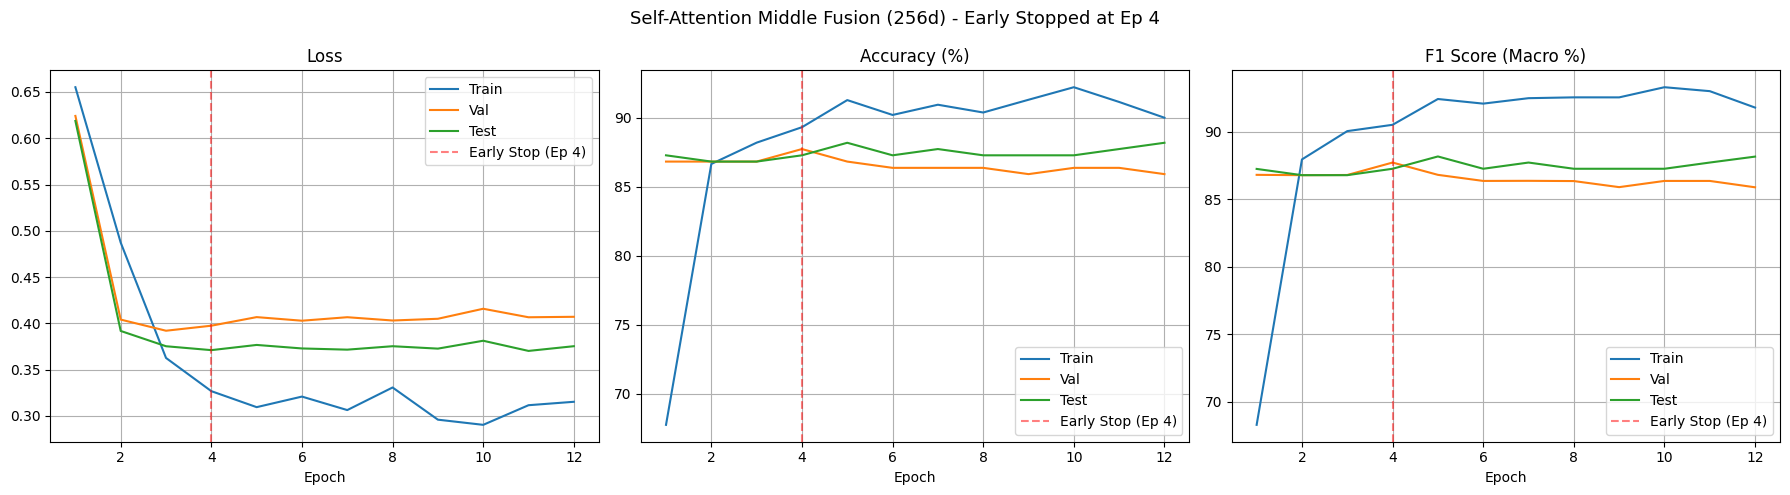


[1] 혼동 행렬 (Confusion Matrix) 분석
                예측 Class 0    예측 Class 1
실제 Class 0 :       101         11
실제 Class 1 :       17          91
------------------------------------------------------------
• 정상 분류된 0번 감정 (True Negative) : 101개
• 0번인데 1번으로 오답 분류 (False Positive) : 11개
• 1번인데 0번으로 오답 분류 (False Negative) : 17개
• 정상 분류된 1번 감정 (True Positive)  : 91개

[2] 상세 성능 성적표 (Classification Report)
              precision    recall  f1-score   support

    Negative       0.86      0.90      0.88       112
    Positive       0.89      0.84      0.87       108

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220



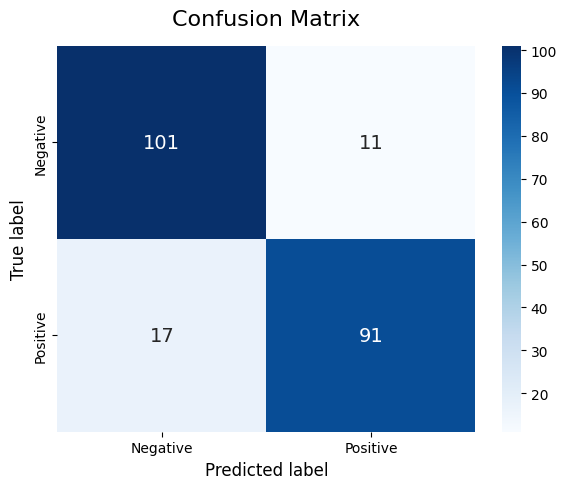


[Ablation Study] 모달리티 기여도 분석 시작
• Video only                     : 64.09%
• Text only                      : 85.00%
• Audio only                     : 70.00%
• Video + Text (Audio masked)    : 85.00%
• Video + Audio (Text masked)    : 73.64%
• Text + Audio (Video masked)    : 86.36%
• All modalities (full)          : 87.27%


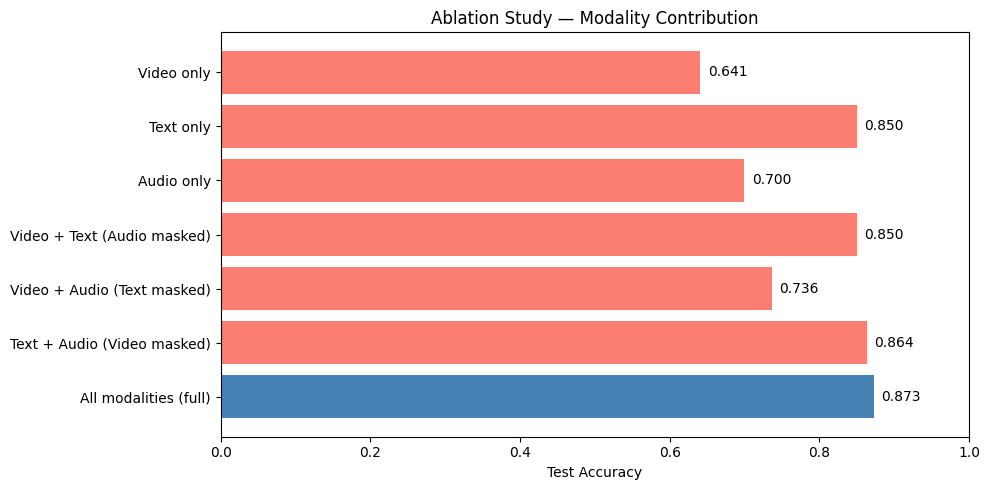


[Attention] 모델이 어떤 모달리티에 집중했는지 확인합니다.
test local index: 0
true=0  pred=1  P(Positive)=0.879

[Source modality mean attention scores]
Video: 0.231
Audio: 0.398
 Text: 0.371


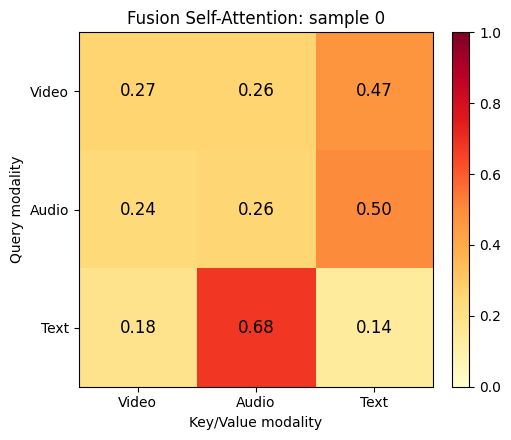


 [3] 개별 샘플 실시간 감정 추론 결과
------------------------------------------------------------
• Class 0번 감정 확률: 12.07%
• Class 1번 감정 확률: 87.93%
------------------------------------------------------------


In [400]:
model_256, hist_256 = run_experiment(
    in_dim     = 256,
    text_path  = "pkl/text_features_256(basic+earlystop).pkl",
    audio_path = "pkl/audio_feat_hubert_origin.pkl",
    video_path = "pkl/video_features_256.pkl",
    hyp        = hyp
)

# 256 텍스트만 증강


[실험 시작] 차원: 256d
데이터 로딩 중...
파라미터 수: 126,018
----------------------------------------------------------------------
Ep   1 Loss 0.648/0.607/0.605 | Acc 69.4/85.0/88.2% | F1 70.3/85.0/88.2% ✓
Ep   2 Loss 0.490/0.394/0.391 | Acc 84.8/86.8/85.9% | F1 86.2/86.8/85.9% ✓
Ep   3 Loss 0.373/0.378/0.369 | Acc 87.1/86.4/86.8% | F1 88.9/86.4/86.8%
Ep   4 Loss 0.337/0.387/0.369 | Acc 88.3/85.9/85.5% | F1 89.3/85.9/85.4%
Ep   5 Loss 0.321/0.393/0.372 | Acc 90.1/85.5/86.8% | F1 91.0/85.4/86.8%
Ep   6 Loss 0.331/0.390/0.368 | Acc 89.8/85.9/86.8% | F1 91.5/85.9/86.8%
Ep   7 Loss 0.316/0.398/0.372 | Acc 90.6/85.9/86.8% | F1 92.0/85.9/86.8%
Ep   8 Loss 0.338/0.399/0.374 | Acc 89.2/85.5/86.4% | F1 91.3/85.5/86.3%
Ep   9 Loss 0.300/0.402/0.374 | Acc 90.8/85.9/86.4% | F1 92.0/85.9/86.3%
Ep  10 Loss 0.303/0.407/0.373 | Acc 90.6/85.9/86.4% | F1 91.5/85.9/86.3%
  → Early stop (epoch 10)

[256d] Best Val Acc  : 86.82%
[256d] 최종 Test Acc : 85.91%
[256d] 최종 Test F1  : 85.90%


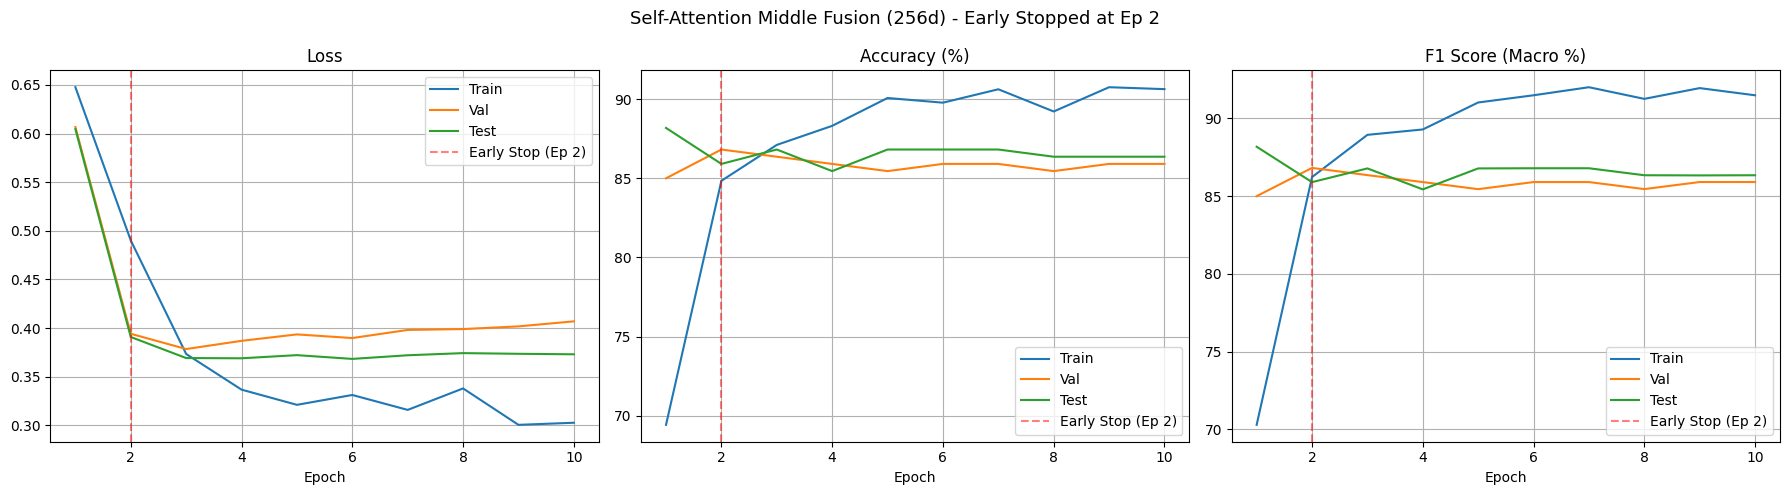


[1] 혼동 행렬 (Confusion Matrix) 분석
                예측 Class 0    예측 Class 1
실제 Class 0 :       97          15
실제 Class 1 :       16          92
------------------------------------------------------------
• 정상 분류된 0번 감정 (True Negative) : 97개
• 0번인데 1번으로 오답 분류 (False Positive) : 15개
• 1번인데 0번으로 오답 분류 (False Negative) : 16개
• 정상 분류된 1번 감정 (True Positive)  : 92개

[2] 상세 성능 성적표 (Classification Report)
              precision    recall  f1-score   support

    Negative       0.86      0.87      0.86       112
    Positive       0.86      0.85      0.86       108

    accuracy                           0.86       220
   macro avg       0.86      0.86      0.86       220
weighted avg       0.86      0.86      0.86       220



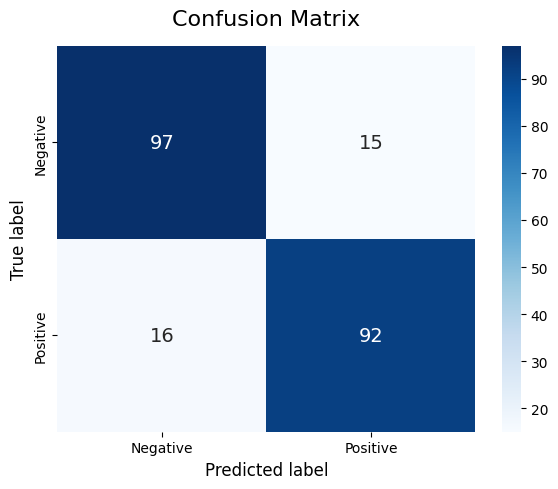


[Ablation Study] 모달리티 기여도 분석 시작
• Video only                     : 59.09%
• Text only                      : 83.18%
• Audio only                     : 69.09%
• Video + Text (Audio masked)    : 83.64%
• Video + Audio (Text masked)    : 69.55%
• Text + Audio (Video masked)    : 85.00%
• All modalities (full)          : 85.91%


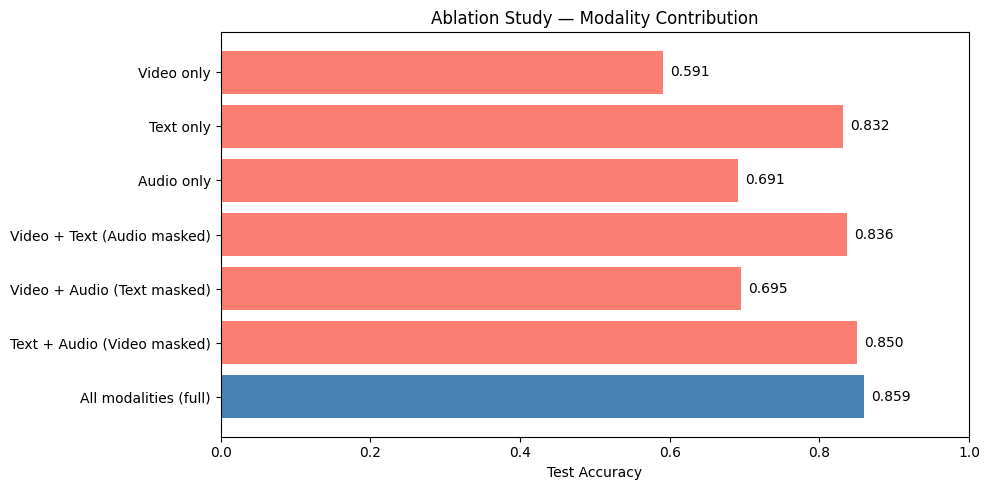


[Attention] 모델이 어떤 모달리티에 집중했는지 확인합니다.
test local index: 0
true=0  pred=1  P(Positive)=0.691

[Source modality mean attention scores]
Video: 0.224
Audio: 0.307
 Text: 0.469


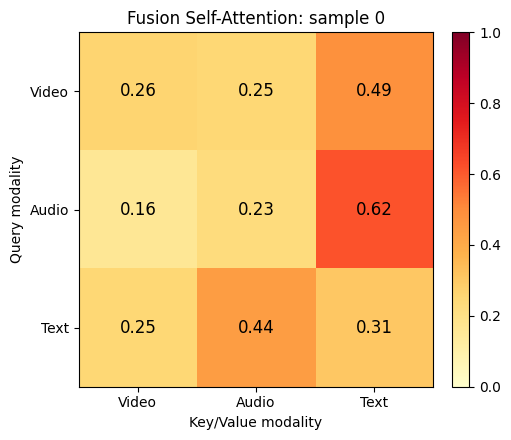


 [3] 개별 샘플 실시간 감정 추론 결과
------------------------------------------------------------
• Class 0번 감정 확률: 30.95%
• Class 1번 감정 확률: 69.05%
------------------------------------------------------------


In [401]:
model_aug256, hist_aug256 = run_experiment(
    in_dim     = 256,
    text_path  = "pkl/text_features_256(증강+동결6+earlystop).pkl",
    audio_path = "pkl/audio_feat_hubert_origin.pkl",
    video_path = "pkl/video_features_256.pkl",
    hyp        = hyp
)

# 256 오디오만 증강


[실험 시작] 차원: 256d
데이터 로딩 중...
파라미터 수: 126,018
----------------------------------------------------------------------
Ep   1 Loss 0.656/0.626/0.621 | Acc 66.5/86.4/86.4% | F1 66.9/86.3/86.3% ✓
Ep   2 Loss 0.488/0.405/0.392 | Acc 86.9/86.8/86.8% | F1 88.4/86.8/86.8% ✓
Ep   3 Loss 0.362/0.392/0.373 | Acc 88.2/86.4/87.3% | F1 90.2/86.3/87.2%
Ep   4 Loss 0.325/0.398/0.366 | Acc 89.4/86.8/87.7% | F1 90.6/86.8/87.7% ✓
Ep   5 Loss 0.309/0.407/0.371 | Acc 91.0/86.8/87.3% | F1 92.2/86.8/87.2%
Ep   6 Loss 0.320/0.402/0.366 | Acc 90.6/86.4/86.8% | F1 92.4/86.3/86.8%
Ep   7 Loss 0.306/0.406/0.364 | Acc 90.6/86.4/87.7% | F1 92.2/86.3/87.7%
Ep   8 Loss 0.332/0.402/0.369 | Acc 90.0/86.4/87.3% | F1 92.1/86.3/87.2%
Ep   9 Loss 0.295/0.404/0.366 | Acc 91.7/86.4/88.2% | F1 92.9/86.3/88.1%
Ep  10 Loss 0.290/0.413/0.373 | Acc 92.1/85.9/88.2% | F1 93.2/85.9/88.1%
Ep  11 Loss 0.312/0.404/0.363 | Acc 90.8/85.9/88.6% | F1 92.5/85.9/88.6%
Ep  12 Loss 0.314/0.406/0.367 | Acc 90.3/85.9/88.2% | F1 92.1/85.9/88.1%
 

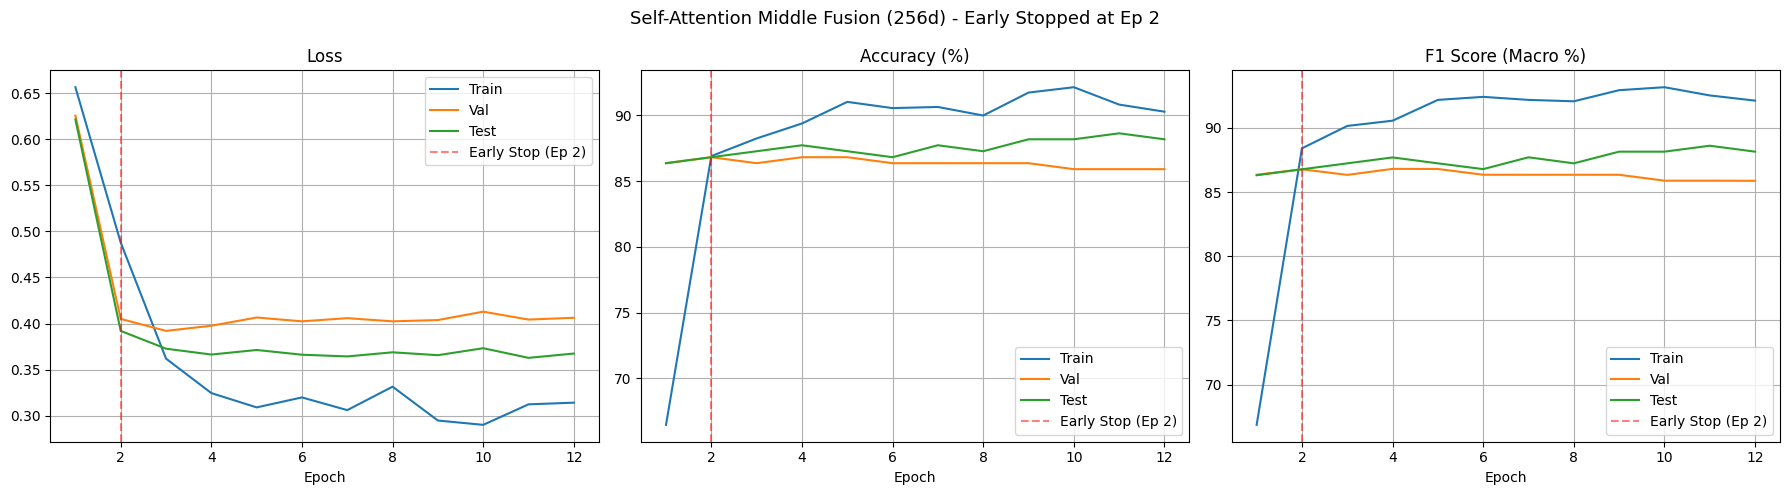


[1] 혼동 행렬 (Confusion Matrix) 분석
                예측 Class 0    예측 Class 1
실제 Class 0 :       102         10
실제 Class 1 :       17          91
------------------------------------------------------------
• 정상 분류된 0번 감정 (True Negative) : 102개
• 0번인데 1번으로 오답 분류 (False Positive) : 10개
• 1번인데 0번으로 오답 분류 (False Negative) : 17개
• 정상 분류된 1번 감정 (True Positive)  : 91개

[2] 상세 성능 성적표 (Classification Report)
              precision    recall  f1-score   support

    Negative       0.86      0.91      0.88       112
    Positive       0.90      0.84      0.87       108

    accuracy                           0.88       220
   macro avg       0.88      0.88      0.88       220
weighted avg       0.88      0.88      0.88       220



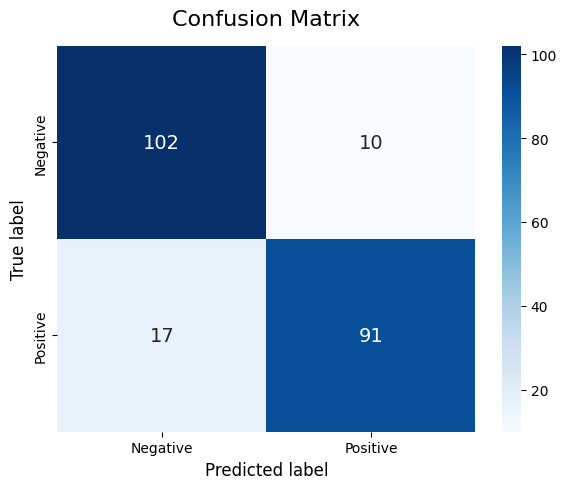


[Ablation Study] 모달리티 기여도 분석 시작
• Video only                     : 64.09%
• Text only                      : 85.00%
• Audio only                     : 72.27%
• Video + Text (Audio masked)    : 85.00%
• Video + Audio (Text masked)    : 70.91%
• Text + Audio (Video masked)    : 86.82%
• All modalities (full)          : 87.73%


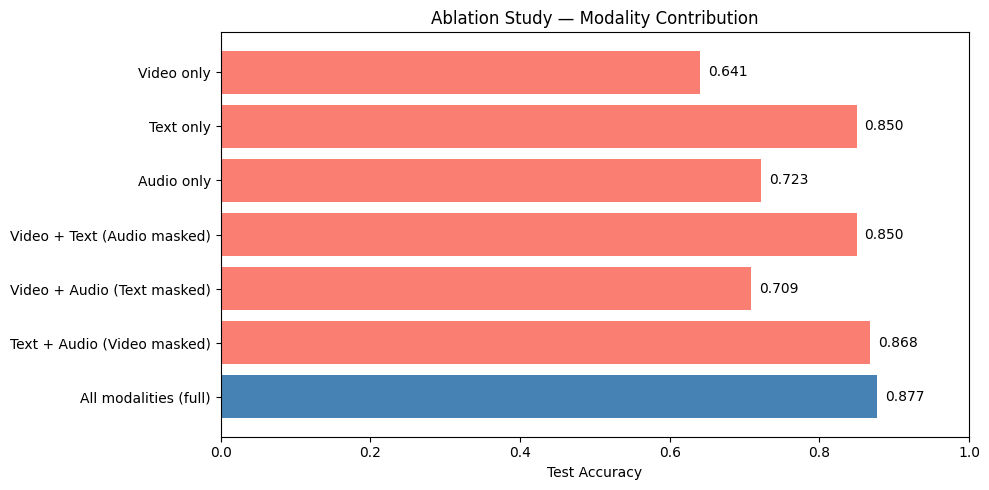


[Attention] 모델이 어떤 모달리티에 집중했는지 확인합니다.
test local index: 0
true=0  pred=1  P(Positive)=0.879

[Source modality mean attention scores]
Video: 0.217
Audio: 0.396
 Text: 0.386


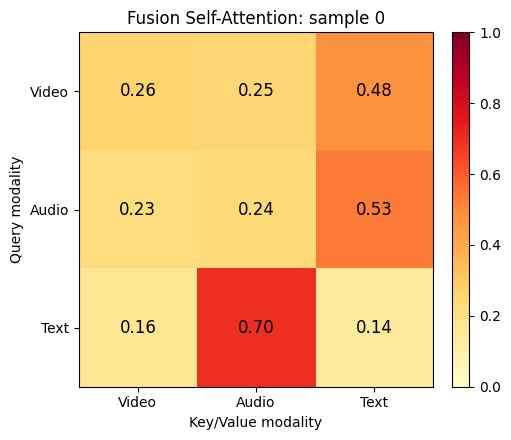


 [3] 개별 샘플 실시간 감정 추론 결과
------------------------------------------------------------
• Class 0번 감정 확률: 12.12%
• Class 1번 감정 확률: 87.88%
------------------------------------------------------------


In [402]:
model_aug256, hist_aug256 = run_experiment(
    in_dim     = 256,
    text_path  = "pkl/text_features_256(basic+earlystop).pkl",
    audio_path = "pkl/audio_feat_hubert_aug.pkl",
    video_path = "pkl/video_features_256.pkl",
    hyp        = hyp
)

# 256 오디오, 텍스트 둘다 증강


[실험 시작] 차원: 256d
데이터 로딩 중...
파라미터 수: 126,018
----------------------------------------------------------------------
Ep   1 Loss 0.649/0.609/0.608 | Acc 68.7/85.5/86.4% | F1 69.5/85.5/86.4% ✓
Ep   2 Loss 0.492/0.396/0.391 | Acc 84.7/85.5/86.8% | F1 86.2/85.5/86.8%
Ep   3 Loss 0.372/0.381/0.367 | Acc 87.4/86.4/86.8% | F1 89.2/86.3/86.8% ✓
Ep   4 Loss 0.336/0.388/0.364 | Acc 88.3/85.5/85.5% | F1 89.3/85.5/85.4%
Ep   5 Loss 0.321/0.395/0.367 | Acc 89.9/86.4/85.9% | F1 90.8/86.3/85.9%
Ep   6 Loss 0.330/0.390/0.362 | Acc 90.2/85.0/85.9% | F1 91.9/85.0/85.9%
Ep   7 Loss 0.315/0.399/0.366 | Acc 90.9/85.0/86.4% | F1 92.2/85.0/86.3%
Ep   8 Loss 0.338/0.400/0.369 | Acc 89.5/85.5/86.8% | F1 91.6/85.5/86.8%
Ep   9 Loss 0.299/0.403/0.368 | Acc 91.2/84.5/86.8% | F1 92.4/84.5/86.8%
Ep  10 Loss 0.301/0.407/0.365 | Acc 90.6/85.5/86.8% | F1 91.4/85.5/86.8%
Ep  11 Loss 0.323/0.402/0.362 | Acc 90.3/85.5/86.8% | F1 92.2/85.5/86.8%
  → Early stop (epoch 11)

[256d] Best Val Acc  : 86.35%
[256d] 최종 Test Acc 

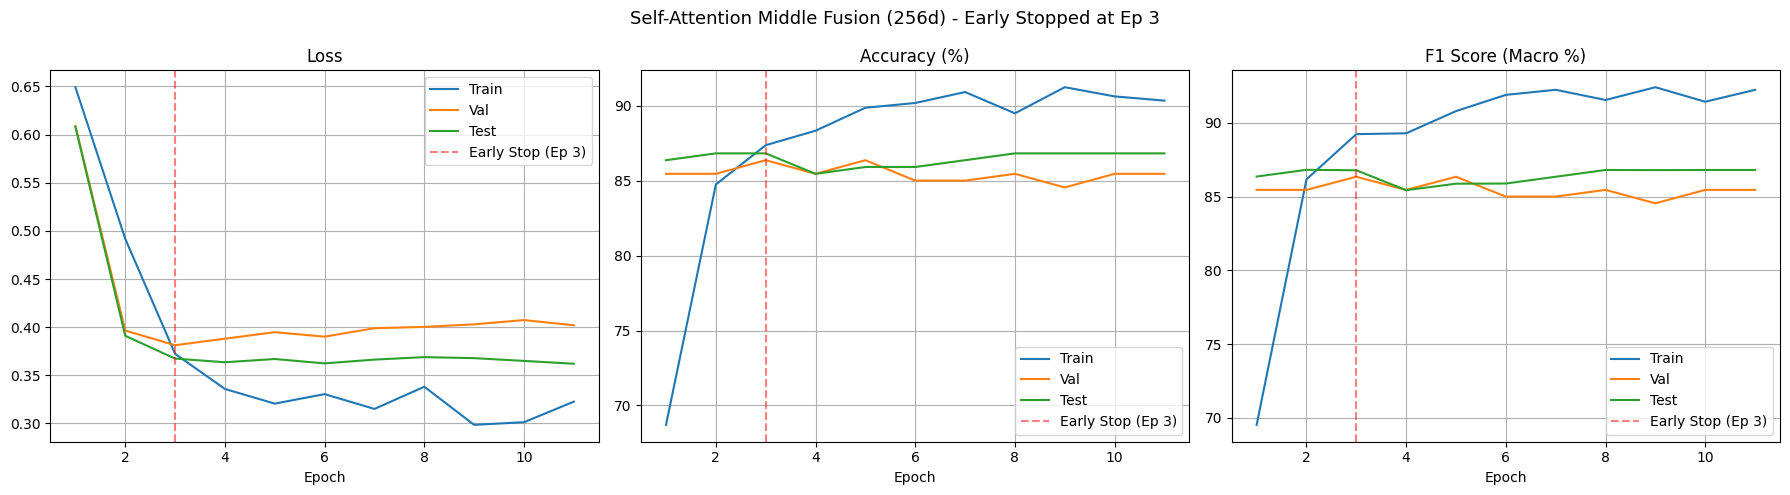


[1] 혼동 행렬 (Confusion Matrix) 분석
                예측 Class 0    예측 Class 1
실제 Class 0 :       101         11
실제 Class 1 :       18          90
------------------------------------------------------------
• 정상 분류된 0번 감정 (True Negative) : 101개
• 0번인데 1번으로 오답 분류 (False Positive) : 11개
• 1번인데 0번으로 오답 분류 (False Negative) : 18개
• 정상 분류된 1번 감정 (True Positive)  : 90개

[2] 상세 성능 성적표 (Classification Report)
              precision    recall  f1-score   support

    Negative       0.85      0.90      0.87       112
    Positive       0.89      0.83      0.86       108

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220



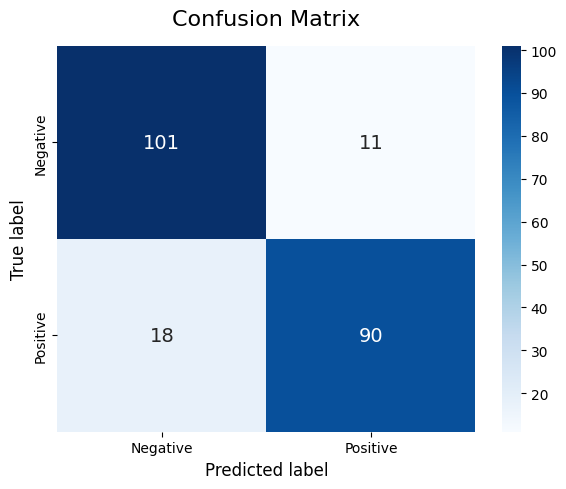


[Ablation Study] 모달리티 기여도 분석 시작
• Video only                     : 64.09%
• Text only                      : 82.73%
• Audio only                     : 68.64%
• Video + Text (Audio masked)    : 85.45%
• Video + Audio (Text masked)    : 72.73%
• Text + Audio (Video masked)    : 85.91%
• All modalities (full)          : 86.82%


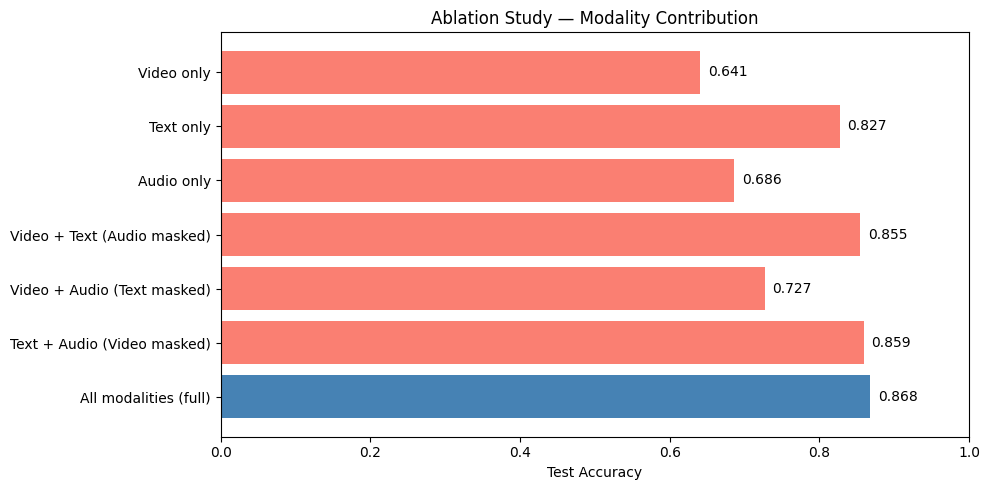


[Attention] 모델이 어떤 모달리티에 집중했는지 확인합니다.
test local index: 0
true=0  pred=1  P(Positive)=0.711

[Source modality mean attention scores]
Video: 0.222
Audio: 0.283
 Text: 0.495


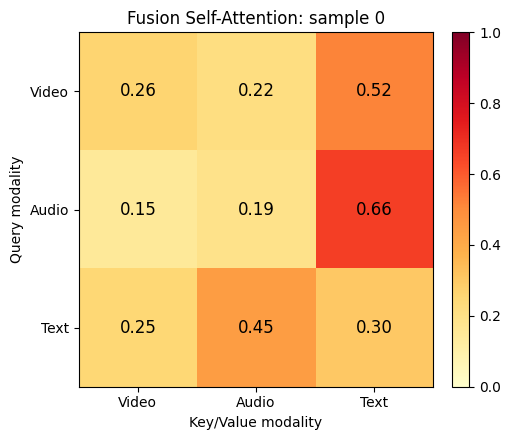


 [3] 개별 샘플 실시간 감정 추론 결과
------------------------------------------------------------
• Class 0번 감정 확률: 28.85%
• Class 1번 감정 확률: 71.15%
------------------------------------------------------------


In [403]:
model_aug256, hist_aug256 = run_experiment(
    in_dim     = 256,
    text_path  = "pkl/text_features_256(증강+동결6+earlystop).pkl",
    audio_path = "pkl/audio_feat_hubert_aug.pkl",
    video_path = "pkl/video_features_256.pkl",
    hyp        = hyp
)

# 기본+756


[실험 시작] 차원: 768d
데이터 로딩 중...
파라미터 수: 227,394
----------------------------------------------------------------------
Ep   1 Loss 0.642/0.566/0.565 | Acc 70.4/86.8/87.7% | F1 71.2/86.8/87.7% ✓
Ep   2 Loss 0.416/0.388/0.376 | Acc 89.2/86.8/87.7% | F1 90.7/86.8/87.7%
Ep   3 Loss 0.354/0.395/0.381 | Acc 88.2/86.8/87.7% | F1 90.3/86.8/87.7%
Ep   4 Loss 0.331/0.388/0.377 | Acc 89.7/86.8/87.7% | F1 91.6/86.8/87.7%
Ep   5 Loss 0.333/0.381/0.375 | Acc 89.3/86.8/88.2% | F1 91.0/86.8/88.2%
Ep   6 Loss 0.320/0.392/0.383 | Acc 90.7/86.8/87.3% | F1 92.5/86.8/87.3%
Ep   7 Loss 0.313/0.367/0.373 | Acc 91.1/87.7/89.1% | F1 92.7/87.7/89.1% ✓
Ep   8 Loss 0.313/0.364/0.369 | Acc 91.0/87.3/88.6% | F1 92.9/87.3/88.6%
Ep   9 Loss 0.285/0.355/0.372 | Acc 92.7/88.2/90.0% | F1 94.3/88.2/90.0% ✓
Ep  10 Loss 0.290/0.353/0.366 | Acc 92.1/88.2/89.1% | F1 93.3/88.2/89.1%
Ep  11 Loss 0.292/0.351/0.365 | Acc 91.7/88.2/89.1% | F1 93.7/88.2/89.1%
Ep  12 Loss 0.284/0.349/0.360 | Acc 91.9/87.3/88.2% | F1 93.4/87.3/88.2%
E

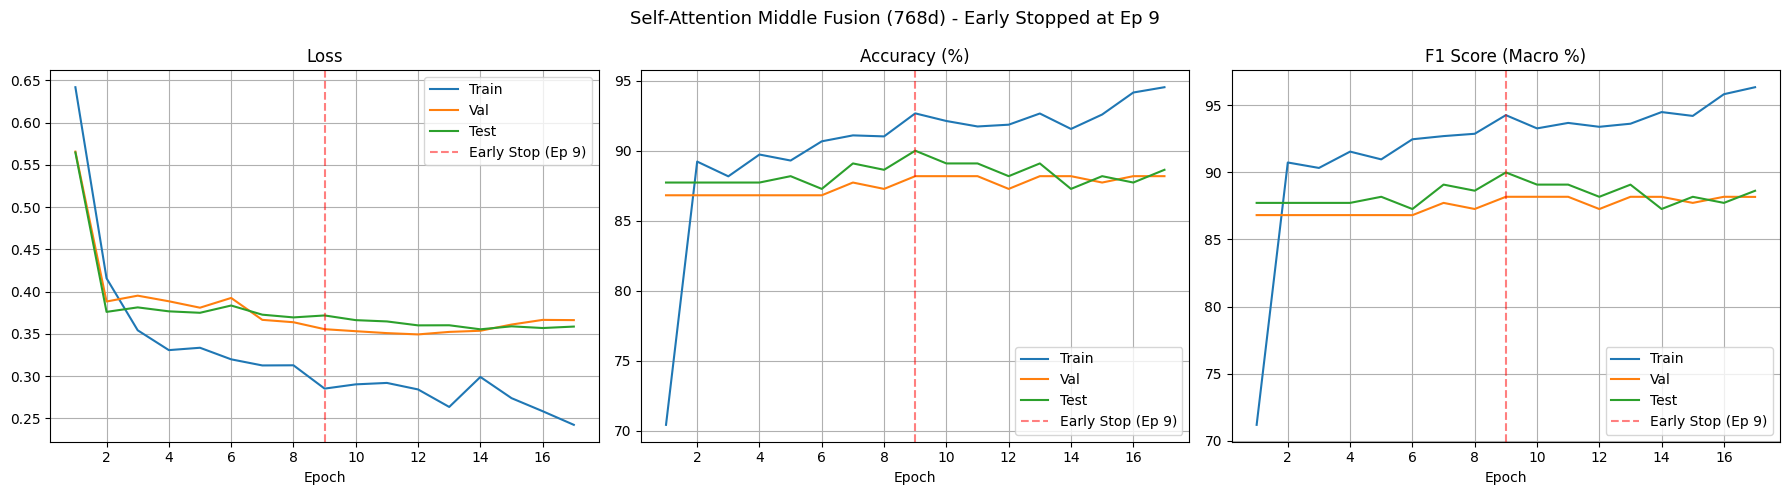


[1] 혼동 행렬 (Confusion Matrix) 분석
                예측 Class 0    예측 Class 1
실제 Class 0 :       101         11
실제 Class 1 :       11          97
------------------------------------------------------------
• 정상 분류된 0번 감정 (True Negative) : 101개
• 0번인데 1번으로 오답 분류 (False Positive) : 11개
• 1번인데 0번으로 오답 분류 (False Negative) : 11개
• 정상 분류된 1번 감정 (True Positive)  : 97개

[2] 상세 성능 성적표 (Classification Report)
              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90       112
    Positive       0.90      0.90      0.90       108

    accuracy                           0.90       220
   macro avg       0.90      0.90      0.90       220
weighted avg       0.90      0.90      0.90       220



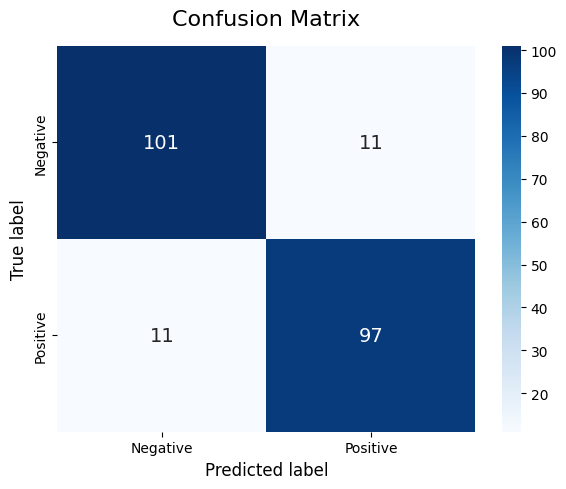


[Ablation Study] 모달리티 기여도 분석 시작
• Video only                     : 58.64%
• Text only                      : 87.73%
• Audio only                     : 54.09%
• Video + Text (Audio masked)    : 89.55%
• Video + Audio (Text masked)    : 59.09%
• Text + Audio (Video masked)    : 87.73%
• All modalities (full)          : 90.00%


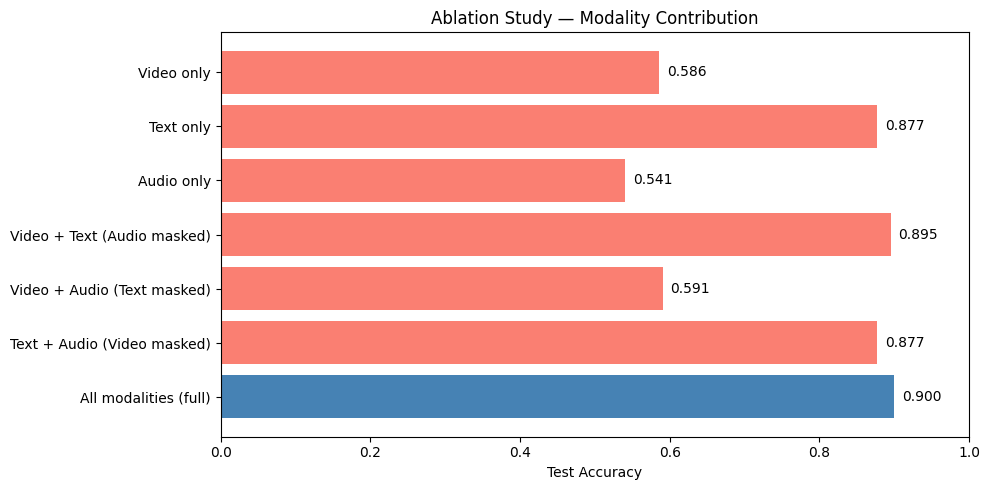


[Attention] 모델이 어떤 모달리티에 집중했는지 확인합니다.
test local index: 0
true=0  pred=1  P(Positive)=0.926

[Source modality mean attention scores]
Video: 0.321
Audio: 0.258
 Text: 0.421


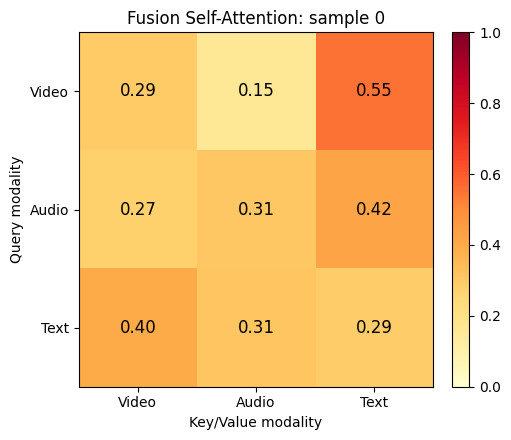


 [3] 개별 샘플 실시간 감정 추론 결과
------------------------------------------------------------
• Class 0번 감정 확률: 7.45%
• Class 1번 감정 확률: 92.55%
------------------------------------------------------------


In [404]:
model_768, hist_768 = run_experiment(
    in_dim     = 768,
    text_path  = "pkl/text_features_768(basic+earlystop).pkl",
    audio_path = "pkl/audio_hubert_768.pkl",
    video_path = "pkl/video_features_768.pkl",
    hyp        = hyp
)

# 768 증강


[실험 시작] 차원: 768d
데이터 로딩 중...
파라미터 수: 227,394
----------------------------------------------------------------------
Ep   1 Loss 0.630/0.561/0.560 | Acc 71.4/86.4/83.6% | F1 72.2/86.3/83.6% ✓
Ep   2 Loss 0.448/0.391/0.399 | Acc 85.1/87.3/83.6% | F1 86.0/87.3/83.6% ✓
Ep   3 Loss 0.401/0.390/0.401 | Acc 84.7/87.3/83.6% | F1 86.3/87.3/83.6% ✓
Ep   4 Loss 0.381/0.389/0.401 | Acc 86.4/86.4/84.1% | F1 87.6/86.4/84.1%
Ep   5 Loss 0.368/0.385/0.401 | Acc 86.2/87.3/84.5% | F1 87.4/87.3/84.5%
Ep   6 Loss 0.359/0.391/0.407 | Acc 87.8/85.9/84.5% | F1 89.3/85.9/84.5%
Ep   7 Loss 0.343/0.382/0.405 | Acc 89.0/85.9/84.5% | F1 90.3/85.9/84.5%
Ep   8 Loss 0.353/0.375/0.398 | Acc 88.2/87.3/83.6% | F1 89.8/87.3/83.6%
Ep   9 Loss 0.314/0.378/0.409 | Acc 90.5/85.9/84.1% | F1 91.7/85.9/84.1%
Ep  10 Loss 0.325/0.379/0.410 | Acc 89.5/86.4/83.2% | F1 90.4/86.3/83.2%
Ep  11 Loss 0.326/0.379/0.406 | Acc 90.1/85.0/86.4% | F1 92.0/85.0/86.4%
  → Early stop (epoch 11)

[768d] Best Val Acc  : 87.26%
[768d] 최종 Test Ac

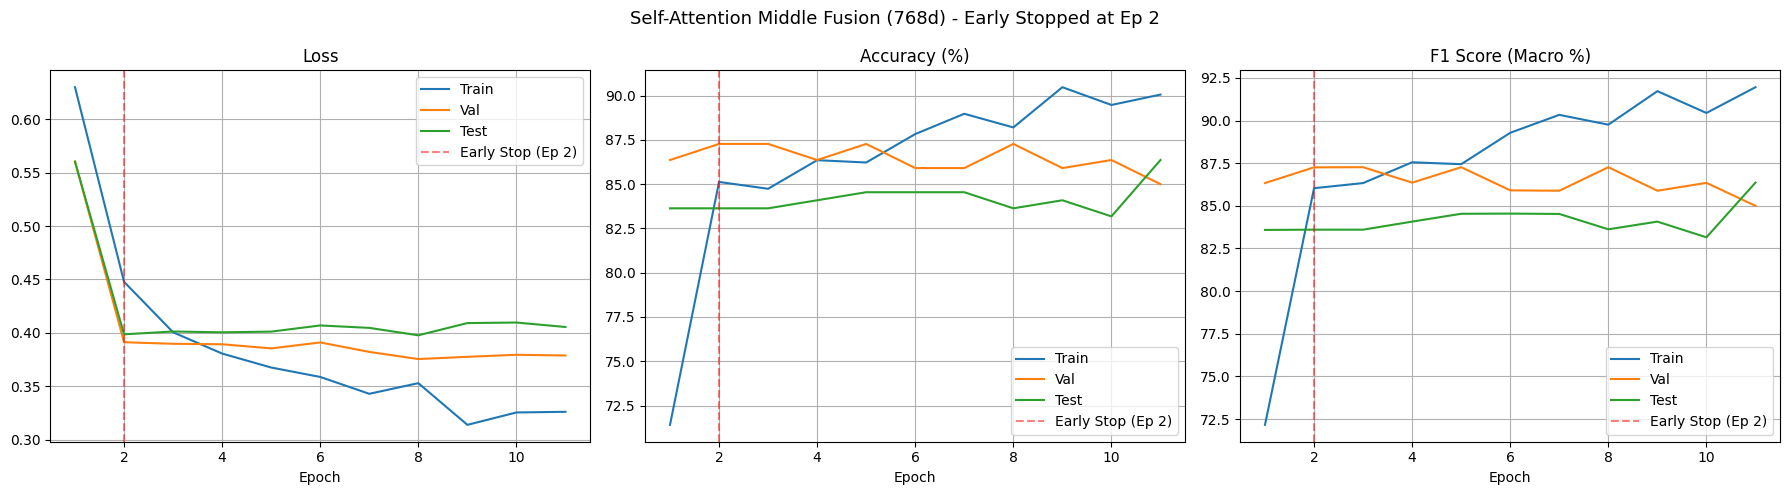


[1] 혼동 행렬 (Confusion Matrix) 분석
                예측 Class 0    예측 Class 1
실제 Class 0 :       97          15
실제 Class 1 :       21          87
------------------------------------------------------------
• 정상 분류된 0번 감정 (True Negative) : 97개
• 0번인데 1번으로 오답 분류 (False Positive) : 15개
• 1번인데 0번으로 오답 분류 (False Negative) : 21개
• 정상 분류된 1번 감정 (True Positive)  : 87개

[2] 상세 성능 성적표 (Classification Report)
              precision    recall  f1-score   support

    Negative       0.82      0.87      0.84       112
    Positive       0.85      0.81      0.83       108

    accuracy                           0.84       220
   macro avg       0.84      0.84      0.84       220
weighted avg       0.84      0.84      0.84       220



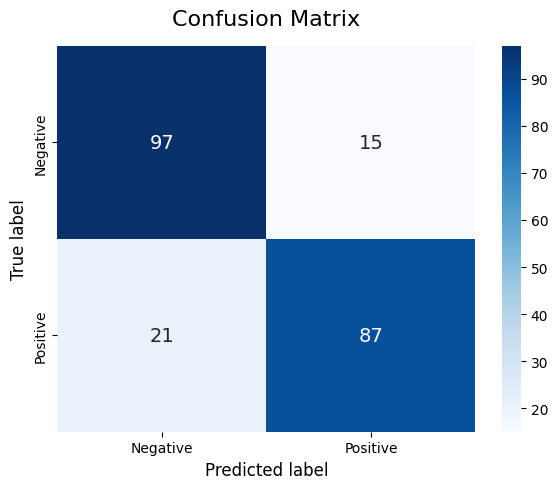


[Ablation Study] 모달리티 기여도 분석 시작
• Video only                     : 57.27%
• Text only                      : 83.64%
• Audio only                     : 50.91%
• Video + Text (Audio masked)    : 83.64%
• Video + Audio (Text masked)    : 60.45%
• Text + Audio (Video masked)    : 83.64%
• All modalities (full)          : 83.64%


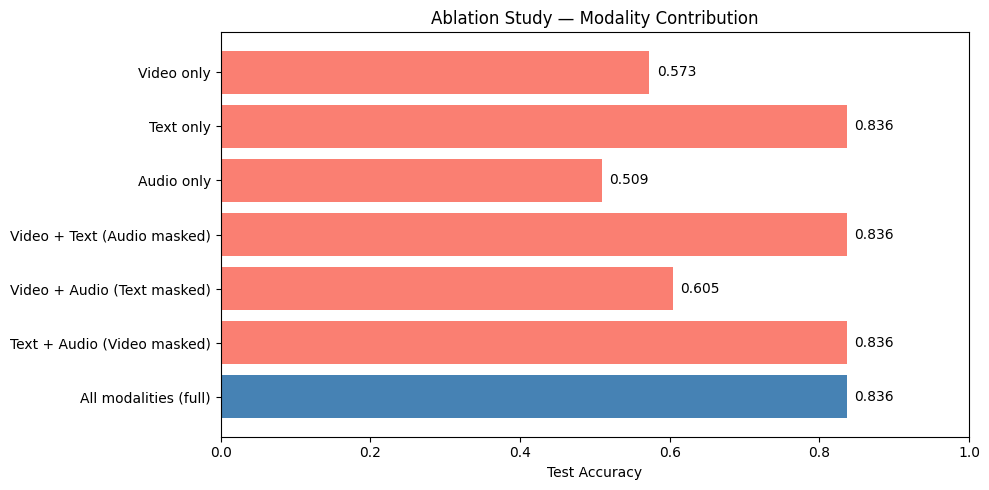


[Attention] 모델이 어떤 모달리티에 집중했는지 확인합니다.
test local index: 0
true=0  pred=1  P(Positive)=0.721

[Source modality mean attention scores]
Video: 0.304
Audio: 0.248
 Text: 0.448


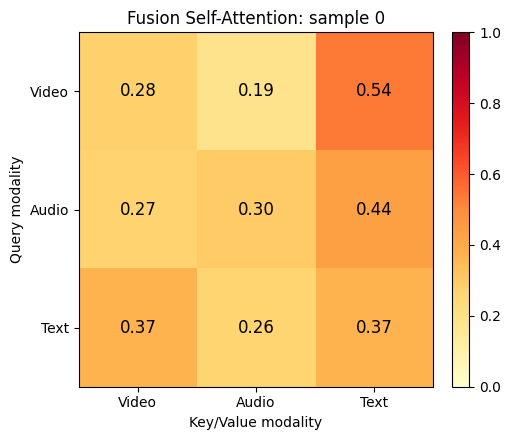


 [3] 개별 샘플 실시간 감정 추론 결과
------------------------------------------------------------
• Class 0번 감정 확률: 27.86%
• Class 1번 감정 확률: 72.14%
------------------------------------------------------------


In [405]:
model_aug768, hist_aug768 = run_experiment(
    in_dim     = 768,
    text_path  = "pkl/text_features_768(증강+동결6+earlystop).pkl",
    audio_path = "pkl/audio_hubert_768.pkl",
    video_path = "pkl/video_features_768.pkl",
    hyp        = hyp
)